In [1]:
# === Colab bootstrap (no-op outside Colab) ===========================
# Clones the repo, installs minimal deps, mounts Google Drive, and
# symlinks heavy assets from Drive into the paths the notebook uses.
# See COLAB_SETUP.md for details.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, subprocess, sys
    REPO = "/content/INF8225_Projet"
    if not os.path.isdir(REPO):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/Azcatchi17/INF8225_Projet.git", REPO,
        ])
    if os.getcwd() != REPO:
        os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    from colab.setup import setup
    setup()
# ======================================================================

In [2]:
import os

# Remonte l'arborescence jusqu'à trouver le dossier racine (qui contient 'data' ou 'MedSAM')
while not os.path.isdir('data') and os.getcwd() != os.path.abspath(os.sep):
    os.chdir('..')
print("Dossier de travail actuel :", os.getcwd())

Dossier de travail actuel : /home/paulb/INF8225/Projet


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from MedSAM.segment_anything import sam_model_registry
from MedSAM.MedSAM_Inference import medsam_inference
from utils import calculate_dice, load_rgb_image, show_segmentation
from skimage import io, transform
from tqdm import tqdm

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Appareil détecté : {device}")

medsam_model = sam_model_registry["vit_b"](checkpoint="MedSAM/work_dir/MedSAM/medsam_vit_b.pth")
medsam_model = medsam_model.to(device)
medsam_model.eval()

Appareil détecté : cuda


/home/paulb/INF8225/Projet/MedSAM/segment_anything/build_sam.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f, map_location=torch.device('cpu'

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [5]:
# --- 1. GESTION DES CHEMINS ---
img_folder = "data/Kvasir-SEG/images"
masks_folder = "data/Kvasir-SEG/masks"

results_folder = "results/kvasir"
os.makedirs(results_folder, exist_ok=True)

output_masks_folder = os.path.join(results_folder, "oracle_segmentation_masks_kvasir")
os.makedirs(output_masks_folder, exist_ok=True)

csv_output_path = os.path.join(results_folder, "dice_oracle_kvasir.csv")

with open("data/Kvasir-SEG/kavsir_bboxes.json") as f:
    bboxes = json.load(f)

# --- 2. VÉRIFICATION DE L'EXISTENCE DES RÉSULTATS ---
if os.path.exists(csv_output_path):
    print(f"Les résultats existent déjà dans {csv_output_path}.")
    print("Inférence ignorée. Chargement des données existantes...")
    df = pd.read_csv(csv_output_path)
    
else:
    # --- 3. PRÉPARATION DES DONNÉES SI INFÉRENCE NÉCESSAIRE ---
    image_to_split = {}
    for split_name in ['train', 'val', 'test']:
        split_file = f"data/Kvasir-SEG/{split_name}.json"
        if os.path.exists(split_file):
            with open(split_file, 'r') as f:
                coco_data = json.load(f)
                for img_info in coco_data['images']:
                    img_id = os.path.splitext(img_info['file_name'])[0]
                    image_to_split[img_id] = split_name

    dice_list = []
    print("Lancement de la segmentation MedSAM (Oracle)...")

    # --- 4. BOUCLE D'INFÉRENCE ---
    for img in tqdm(os.listdir(img_folder), desc="Segmentation MedSAM"):
        img_path = os.path.join(img_folder, img)
        img_id = os.path.splitext(img)[0]
        
        split = image_to_split.get(img_id, "unknown")

        img_3c = load_rgb_image(img_path)
        H, W, _ = img_3c.shape

        img_1024 = transform.resize(
            img_3c, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True
        ).astype(np.uint8)
        
        img_1024 = (img_1024 - img_1024.min()) / np.clip(
            img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None
        )
        
        img_1024_tensor = (
            torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)
        )

        with torch.no_grad():
            image_embedding = medsam_model.image_encoder(img_1024_tensor)

        full_medsam_seg = np.zeros((H, W), dtype=np.uint8)

        if img_id in bboxes:
            for bbox in bboxes[img_id]["bbox"]:
                x_min, y_min = bbox["xmin"], bbox["ymin"]
                x_max, y_max = bbox["xmax"], bbox["ymax"]
            
                box_np = np.array([[x_min, y_min, x_max, y_max]]) 
                box_1024 = box_np / np.array([W, H, W, H]) * 1024

                medsam_seg = medsam_inference(medsam_model, image_embedding, box_1024, H, W)

                full_medsam_seg[medsam_seg > 0] = 1

        io.imsave(
            os.path.join(output_masks_folder, "seg_" + os.path.basename(img_path)),
            (full_medsam_seg*255).astype(np.uint8),
            check_contrast=False,
        )

        mask_path = os.path.join(masks_folder, img)
        if os.path.exists(mask_path):
            true_seg = io.imread(mask_path)
            if len(true_seg.shape) == 3:
                true_seg = true_seg[:,:,0]
            true_seg[true_seg > 0] = 1

            dice_score = calculate_dice(true_seg, full_medsam_seg)

            dice_list.append({
                "image_id": img_id,
                "split": split,
                "dice": dice_score
            })

    df = pd.DataFrame(dice_list)
    df.to_csv(csv_output_path, index=False)
    print(f"\nRésultats sauvegardés dans : {csv_output_path}")

# --- 5. ANALYSE (Exécutée dans tous les cas) ---
print("\n=== STATISTIQUES GLOBALES ORACLE ===")
print(df['dice'].describe())

print("\n=== STATISTIQUES PAR SET ===")
print(df.groupby('split')['dice'].describe())

Les résultats existent déjà dans results/kvasir/dice_oracle_kvasir.csv.
Inférence ignorée. Chargement des données existantes...

=== STATISTIQUES GLOBALES ORACLE ===
count    1000.000000
mean        0.954298
std         0.024184
min         0.629385
25%         0.944214
50%         0.959542
75%         0.969729
max         0.992421
Name: dice, dtype: float64

=== STATISTIQUES PAR SET ===
       count      mean       std       min       25%       50%       75%  \
split                                                                      
test   100.0  0.951666  0.040432  0.629385  0.941749  0.959893  0.971275   
train  800.0  0.954720  0.021593  0.806905  0.944258  0.959587  0.969656   
val    100.0  0.953558  0.022242  0.874240  0.943697  0.959043  0.969458   

            max  
split            
test   0.984346  
train  0.992421  
val    0.981697  


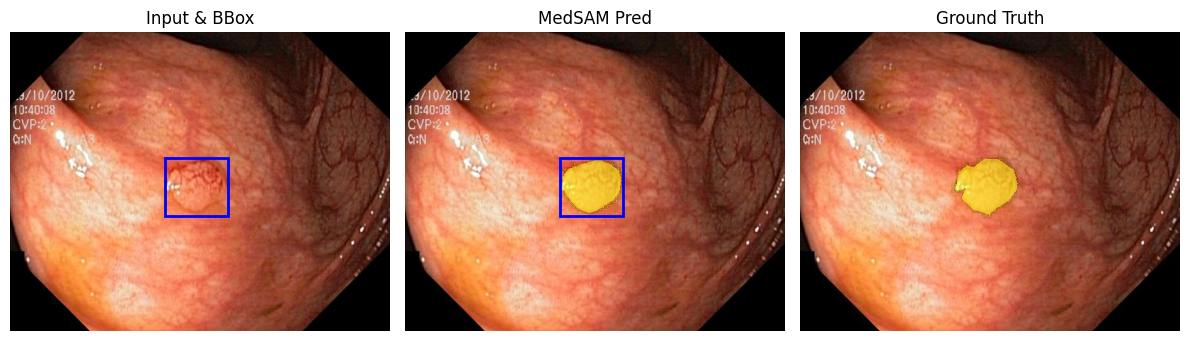

In [6]:
show_segmentation(
    img_name="cju2syxa93yw40799x2iuwabz.jpg",
    img_folder=img_folder,
    masks_folder=masks_folder,
    output_masks_folder=output_masks_folder,
    bboxes=bboxes
)

In [7]:
print(bboxes)

{'cju0qkwl35piu0993l0dewei2': {'height': 529, 'width': 622, 'bbox': [{'label': 'polyp', 'xmin': 38, 'ymin': 5, 'xmax': 430, 'ymax': 338}]}, 'cju0qoxqj9q6s0835b43399p4': {'height': 1070, 'width': 1348, 'bbox': [{'label': 'polyp', 'xmin': 194, 'ymin': 284, 'xmax': 913, 'ymax': 1049}]}, 'cju0qx73cjw570799j4n5cjze': {'height': 529, 'width': 619, 'bbox': [{'label': 'polyp', 'xmin': 187, 'ymin': 14, 'xmax': 543, 'ymax': 526}]}, 'cju0roawvklrq0799vmjorwfv': {'height': 528, 'width': 622, 'bbox': [{'label': 'polyp', 'xmin': 486, 'ymin': 42, 'xmax': 622, 'ymax': 339}, {'label': 'polyp', 'xmin': 329, 'ymin': 71, 'xmax': 437, 'ymax': 150}, {'label': 'polyp', 'xmin': 619, 'ymin': 151, 'xmax': 622, 'ymax': 285}]}, 'cju0rx1idathl0835detmsp84': {'height': 528, 'width': 617, 'bbox': [{'label': 'polyp', 'xmin': 292, 'ymin': 154, 'xmax': 481, 'ymax': 375}]}, 'cju0s2a9ekvms080138tjjpxr': {'height': 547, 'width': 626, 'bbox': [{'label': 'polyp', 'xmin': 379, 'ymin': 57, 'xmax': 626, 'ymax': 431}]}, 'cju0s6